In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
heart_data = pd.read_csv('heart.csv')

In [ ]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# number of rows and columns in the dataset
heart_data.shape

(1025, 14)

In [ ]:
heart_data['target'].value_counts()

,count
target,
1,526
0,499


In [ ]:
print(heart_data.corr()['target'].sort_values(ascending=False))


target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


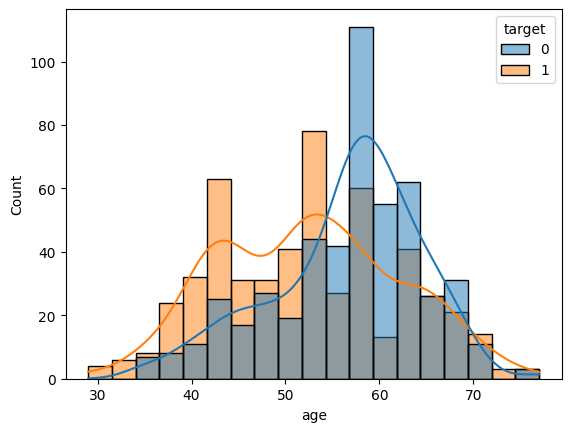

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=heart_data, x='age', hue='target', kde=True)
plt.show()

**Spliting Data**

In [ ]:
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

**Split train test**

In [ ]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y, test_size=0.3, stratify=Y, random_state=2)


In [ ]:
print(X.shape, X_train.shape , X_test.shape)

(1025, 13) (717, 13) (308, 13)


**Model** **Training** **logistic regression**

In [ ]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
model.fit(X_train, Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

In [ ]:
print('Accuracy of the Training data is : ', training_data_accuracy)

Accuracy of the Training data is :  0.8786610878661087


In [ ]:
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)

In [ ]:
print('Accuracy of the Test data is : ', test_data_accuracy)

Accuracy of the Test data is :  0.8051948051948052


In [ ]:
input_data = (58,0,0,100,248,0,0,122,0,1,1,0,2)
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
print(input_data_reshaped)


prediction = model.predict(input_data_reshaped)

if prediction == 0:
  print('The person is not having heart disease')
else:
  print('The person is having heart disease')

[[ 58   0   0 100 248   0   0 122   0   1   1   0   2]]
The person is having heart disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pickle
filename = 'heart_model.sav'
pickle.dump(model, open(filename, 'wb'))


SVM

In [ ]:
from sklearn.svm import SVC
model = SVC(kernel='linear')
model.fit(X_train, Y_train)

X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)
print('SVM Training Accuracy:', training_data_accuracy)

X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)
print('SVM Test Accuracy:', test_data_accuracy)

SVM Training Accuracy: 0.8702928870292888
SVM Test Accuracy: 0.801948051948052


**random forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, Y_train)

X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)
print('Random Forest Training Accuracy:', training_data_accuracy)

X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)
print('Random Forest Test Accuracy:', test_data_accuracy)

Random Forest Training Accuracy: 1.0
Random Forest Test Accuracy: 0.9707792207792207


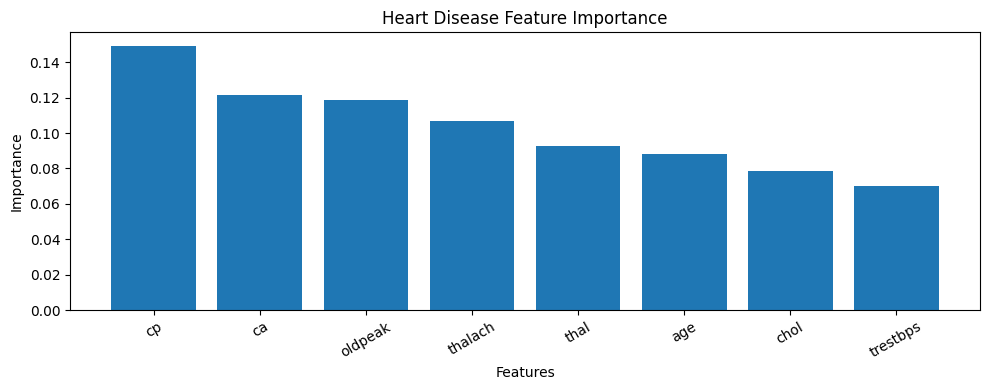

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ---------------- LOAD DATA ----------------
heart = pd.read_csv("heart.csv")

# ---------------- PREPARE DATA ----------------
X = heart.drop(columns=['target'])   # features
Y = heart['target']                # target

# ---------------- TRAIN MODEL ----------------
model = RandomForestClassifier(n_estimators=100)
model.fit(X, Y)

# ---------------- FEATURE IMPORTANCE ----------------
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort (highest first)
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance = feature_importance.head(8)


plt.figure(figsize=(10, 4))

plt.bar(feature_importance['Feature'], feature_importance['Importance'])

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Heart Disease Feature Importance')

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()